1. Load API keys

In [1]:
import os 
from dotenv import load_dotenv

load_dotenv()

True

2. Import Model

from langchain.chat_models import init_chat_model

model = init_chat_model(
    "openai/gpt-oss-20b",
    model_provider="openrouter",
    temperature=0
)


3. Create state

In [2]:
from typing import TypedDict

class State(TypedDict):
    number:int

4. Create increment Node

In [3]:
def increment_number(State):

    new_num = State['number'] + 1
    
    print ('Current number:', new_num)

    return {"number": new_num}

5. Create routing function

In [4]:
def check_number(State):

    if State['number'] < 5:
        return "continue"
    else:
        return "finish"

8. Create Graph

In [5]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

9. Add nodes

In [6]:
builder.add_node("increment_number", increment_number)

10. Add edges

In [7]:
builder.add_edge(START, "increment_number")


builder.add_conditional_edges(
    "increment_number", 
    check_number, 
    {
        "continue": "increment_number",
        "finish": END
    }
)

11. Compile

In [8]:
graph = builder.compile()

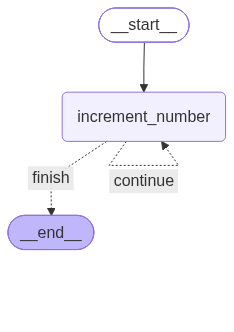

In [9]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

12. Invoke

In [12]:
result = graph.invoke({"number":6 })

Current number: 7


13. Print

In [11]:
print(result["number"])

5
